# W06 · 连续控制：SAC 与 TD3

> 阶段一第 6 周。到目前为止的动作都是离散的（左/右推、四个方向）。
> 真实机器人的动作是**连续力矩/推力**——DQN 的 $\arg\max_a Q(s,a)$ 在连续空间里没法做。
> 本周认识两大 off-policy 连续控制算法：**TD3**（确定性策略）与 **SAC**（最大熵随机策略）。

## 学习目标

1. 解释连续动作为什么让 DQN 失效，以及 Actor-Critic 如何绕开 $\arg\max$；
2. 说出 TD3 相对 DDPG 的三个改进及其各自针对的问题；
3. 写出 SAC 的最大熵目标，解释温度系数 $\alpha$ 的作用与自动调节机制；
4. 在 Pendulum-v1 上对比 SAC 与 TD3，在 MountainCarContinuous-v0 上体验稀疏奖励连续控制；
5. 会用 SB3 训练、评估并画学习曲线（Monitor + 项目 plots 辅助）。

**先修要求**：W04（DQN/经验回放/目标网络）、W05（Actor-Critic 概念）。
预计用时 3–4 小时（含约 5 分钟训练时间）。

## 1. 连续动作的麻烦与 Actor-Critic 解法

DQN 依赖两步离散操作：对所有动作算 $Q$ 值、取 $\arg\max$。
连续空间 $\mathcal{A} = \mathbb{R}^n$ 无法枚举动作——两条出路：

1. **离散化**：把力矩切成若干档。维度灾难（10 个关节 × 每关节 7 档 = $7^{10} \approx 2.8$ 亿个动作），放弃；
2. **Actor-Critic**：让 actor 网络**直接输出连续动作** $a = \mu_\theta(s)$，
   critic 网络评估 $Q(s, a;\phi)$；actor 的更新方向是「让 critic 打更高的分」：
   $$\nabla_\theta J \approx \mathbb{E}_{s \sim \mathcal{D}}\big[\nabla_a Q(s,a;\phi)\big|_{a=\mu_\theta(s)} \nabla_\theta \mu_\theta(s)\big]$$

这就是 **DDPG**（确定性策略梯度，2015）。它同时复用了 DQN 的两块稳定器（回放 + 目标网络），
所以它是 off-policy 的：**样本效率高**，连续机器人任务里几十上百万步（而非 PPO 的千万级）就能出效果。

### 1.1 TD3：修补 DDPG 的三处漏洞

DDPG 实测脆弱（Q 值高估 + 对超参敏感），TD3（2018）加了三个补丁：

| 改进 | 针对的问题 |
|---|---|
| **双 critic（Clipped Double Q）**：取两个 Q 网络的**较小值**算目标 | Q 值高估（W04 练习 2 的 overestimation 在连续版的放大） |
| **延迟更新策略**：critic 更新多次，actor 才更新一次 | actor 追着不准的 critic 跑 |
| **目标策略平滑**：算目标值时给目标动作加 clipped 噪声 | 策略利用 Q 函数的尖锐峰值（过拟合窄峰） |

### 1.2 SAC：把「探索」写进目标函数

SAC（Soft Actor-Critic, 2018）换了个世界观——**最大熵 RL**：

$$\pi^* = \arg\max_\pi \sum_t \mathbb{E}\big[r_t + \alpha\, \mathcal{H}\big(\pi(\cdot|s_t)\big)\big]$$

除了回报，还要**最大化策略的熵** $\mathcal{H}$。温度系数 $\alpha$ 调节两者权重：
$\alpha$ 大 → 策略更随机（多探索、更鲁棒）；$\alpha$ 小 → 更贪心。
实践中 $\alpha$ **自动调节**：优化问题「在保证熵不低于阈值的前提下最大化回报」，$\alpha$ 是对偶变量。

收益：SAC 学出的策略天然保持探索性，对扰动更鲁棒（机器人 Sim2Real 里很看重这点），
且不像 DDPG/TD3 那样依赖外加的探索噪声。
现代 SAC 也用双 critic + 延迟更新——可以把它理解成「TD3 的躯干 + 随机策略 + 熵正则」。

## 2. 实验一：Pendulum-v1 上 SAC vs TD3

Pendulum（倒立摆）：从下垂位置把杆**摆起来并稳定在竖直向上**。

- 观测 3 维：$[\cos\theta, \sin\theta, \dot\theta]$；动作 1 维：力矩 $\in [-2, 2]$；
- 奖励 = $-(\theta^2 + 0.1\dot\theta^2 + 0.001\,u^2)$，**最大为 0**（竖直静止且不发力）；
  随机策略约 $-1200$，训练好的策略约 $-150$ 左右；
- 回合固定 200 步（只有 truncated，没有 terminated）。

各训 10,000 步（CPU 几分钟内），用项目 plots 辅助画对比曲线：

In [1]:
import time
import gymnasium as gym
import matplotlib.pyplot as plt
import torch
from stable_baselines3 import SAC, TD3
from stable_baselines3.common.monitor import Monitor
from robot_rl_learn.common.paths import make_run_dir
from robot_rl_learn.phase1_sb3.train import evaluate
from robot_rl_learn.phase1_sb3.plots import plot_learning_curve

torch.set_num_threads(6)  # MlpPolicy 很小，限线程可与其他任务和平共处

def train_on(env_id, algo_cls, total_timesteps, run_name, seed=0, **kwargs):
    run_dir = make_run_dir(run_name)
    env = Monitor(gym.make(env_id), filename=str(run_dir / "train"))
    model = algo_cls("MlpPolicy", env, seed=seed, verbose=0, device="cpu", **kwargs)
    t0 = time.time()
    model.learn(total_timesteps=total_timesteps)
    mean_r, std_r = evaluate(model, env_id, n_episodes=10)
    print(f"{run_name}: {total_timesteps} 步训练 {time.time() - t0:.0f}s | "
          f"评估 {mean_r:.1f} ± {std_r:.1f}")
    env.close()
    return model, run_dir

runs = {}

In [2]:
_, runs["SAC"] = train_on("Pendulum-v1", SAC, 10_000, "w06_pendulum_sac")

w06_pendulum_sac: 10000 步训练 79s | 评估 -107.7 ± 81.8


w06_pendulum_td3: 10000 步训练 51s | 评估 -109.4 ± 82.7


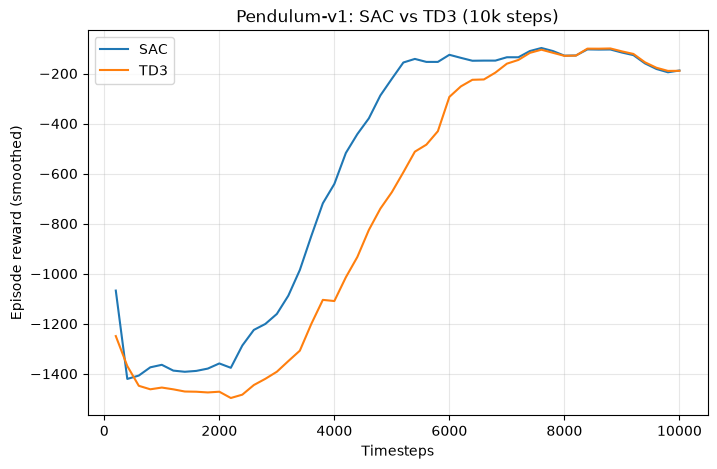

In [3]:
_, runs["TD3"] = train_on("Pendulum-v1", TD3, 10_000, "w06_pendulum_td3")

plot_learning_curve(runs, window=10)
plt.title("Pendulum-v1: SAC vs TD3 (10k steps)")
plt.show()

**典型观察**：两者 1 万步内都能从约 $-1200$ 升到 $-100 \sim -300$ 区间；
SAC 通常在 Pendulum 这类任务上样本效率略好、曲线更平滑，TD3 抖动稍大。
1 万步还不是终点——Zoo 的官方配置训 30 万步能到 $-150$ 附近。
**读图要点**：横轴是环境步数，比较 off-policy 算法就看「同样步数谁更高」（样本效率）。

## 3. 实验二：MountainCarContinuous-v0 —— 稀疏奖励的连续控制

经典 MountainCar 的连续动作版：小车动力不足，**必须先反向荡起来积累势能**才能冲上山。

- 观测 2 维：$[\text{位置}, \text{速度}]$；动作 1 维：推力 $\in [-1, 1]$；
- 奖励**接近稀疏**：到达山顶 +100，每步仅惩罚 $0.1u^2$（不鼓励乱发力）；
- 回合 999 步截断。难点：直接向右推会卡在坡上，得学会「向左荡」——反直觉的探索。

稀疏奖励对 off-policy 的 replay buffer 其实是利好：一旦偶然成功过一次，
成功经验会留在池子里被反复学习。用 TD3 训 4 万步看效果：

w06_mcc_td3: 40000 步训练 201s | 评估 -0.0 ± 0.0


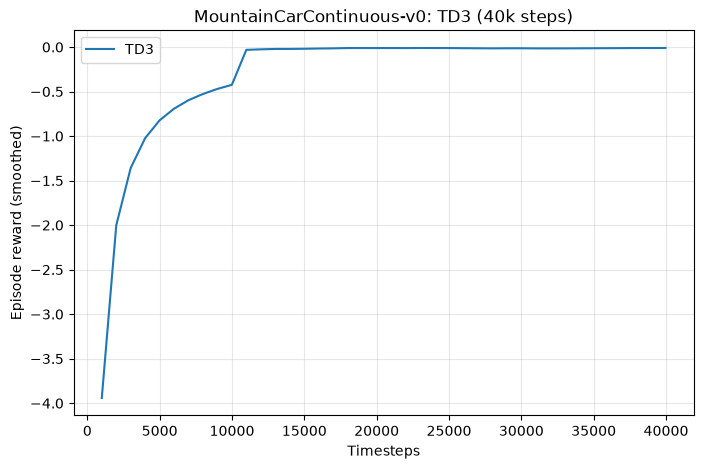

若曲线后段出现 +90 以上的尖峰 → 策略已学会'荡上去'；
若评估回报 ≈ 0 → 策略陷入'干脆不发力'的局部最优（每步仅 -0.1u²，不动反而亏得少），
这是稀疏奖励的经典失败模式：加大步数或换 SAC 再试（练习 3）。


In [4]:
model_mc, run_mc = train_on("MountainCarContinuous-v0", TD3, 40_000, "w06_mcc_td3")

plot_learning_curve({"TD3": run_mc}, window=10)
plt.title("MountainCarContinuous-v0: TD3 (40k steps)")
plt.show()
print("若曲线后段出现 +90 以上的尖峰 → 策略已学会'荡上去'；")
print("若评估回报 ≈ 0 → 策略陷入'干脆不发力'的局部最优（每步仅 -0.1u²，不动反而亏得少），")
print("这是稀疏奖励的经典失败模式：加大步数或换 SAC 再试（练习 3）。")

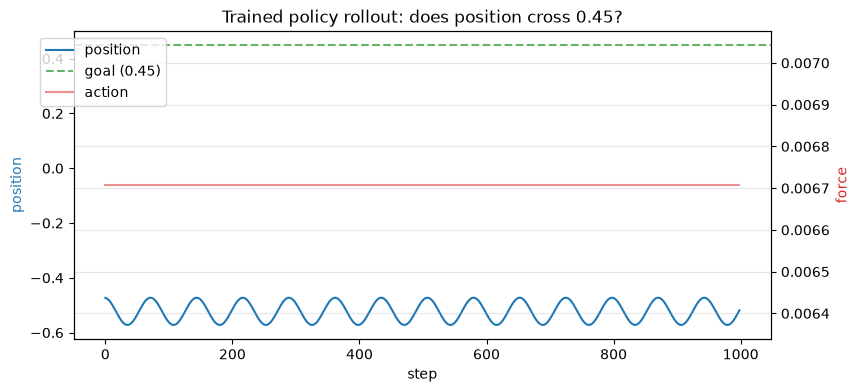

回合结束时位置 = -0.519（>0.45 即成功登顶），共 999 步


In [5]:
# 定性检查：回放训练后策略的一回合轨迹，看是否有「先左荡再右冲」的模式
import numpy as np

env = gym.make("MountainCarContinuous-v0")
obs, _ = env.reset(seed=0)
pos, vel, acts = [], [], []
terminated = truncated = False
while not (terminated or truncated):
    a, _ = model_mc.predict(obs, deterministic=True)
    obs, r, terminated, truncated, _ = env.step(a)
    pos.append(obs[0]); vel.append(obs[1]); acts.append(a[0])
env.close()

fig, ax1 = plt.subplots(figsize=(9, 4))
ax1.plot(pos, color="tab:blue", label="position")
ax1.axhline(0.45, color="g", ls="--", alpha=0.6, label="goal (0.45)")
ax1.set_xlabel("step"); ax1.set_ylabel("position", color="tab:blue")
ax2 = ax1.twinx()
ax2.plot(acts, color="tab:red", alpha=0.5, label="action")
ax2.set_ylabel("force", color="tab:red")
ax1.set_title("Trained policy rollout: does position cross 0.45?")
fig.legend(loc="upper left", bbox_to_anchor=(0.08, 0.88))
plt.grid(alpha=0.3); plt.show()
print(f"回合结束时位置 = {pos[-1]:.3f}（>0.45 即成功登顶），共 {len(pos)} 步")

## 4. SAC vs TD3：选型速查

| | TD3 | SAC |
|---|---|---|
| 策略类型 | 确定性 + 外加探索噪声 | 随机策略（熵内生于目标） |
| 样本效率 | 高 | 高（通常略优） |
| 超参敏感性 | 较敏感（需调 policy_noise 等） | 相对鲁棒（$\alpha$ 自动调） |
| 鲁棒性/探索 | 一般 | 更好（最大熵） |
| 常见用途 | 需要确定性部署的场景 | 默认首选，Sim2Real 友好 |

工程经验：**连续控制新任务先上 SAC**；调不动或需要确定性策略时换 TD3；
预算充足（样本便宜、仿真快）时用 PPO 更省心。RL Baselines3 Zoo 有各环境的参考超参，别从零拍脑袋。

---

## ✏️ 练习

**练习 1（★，10 分钟）——读懂 Pendulum 的奖励**
打印 Pendulum 的观测/动作空间，用代码验证「竖直静止、零力矩」时单步奖励为 0，
「水平静止」时为 $-\pi^2 \approx -9.87$（提示：$\theta$ 从竖直向上为 0 起算，可用
`obs=[cos θ, sin θ, θ̇]` 反推）。
**交付物**：验证 cell + 一行结论。

**练习 2（★★，25 分钟）——种子稳定性**
在 Pendulum 上用 seed=1 重训 SAC 与 TD3（各 1 万步），与正文 seed=0 的曲线画在同一张图。
**交付物**：四曲线图 + 两句话：哪个算法的跨种子一致性更好？这对「论文里只报单个种子」的做法有何启示？

**练习 3（★★，25 分钟）——SAC 攻稀疏奖励**
用 SAC 在 MountainCarContinuous-v0 上训 3 万步，与正文 TD3 的曲线对比。
**交付物**：对比图 + 分析：谁先拿到第一次 +100？用 replay buffer 与最大熵探索解释差异。

**练习 4（★★，20 分钟）——调 TD3 的探索噪声**
SB3 的 TD3 用 `action_noise` 参数控制训练期探索。对比 `NormalActionNoise(σ=0.1)` 与 `σ=0.3`
在 Pendulum 上各 1 万步（`from stable_baselines3.common.noise import NormalActionNoise`）。
**交付物**：对比曲线 + 一句话说明 σ 过大的危害（提示：动作被噪声淹没 ≈ 随机策略）。

---

<details>
<summary>参考答案（做完再点开）</summary>

**练习 1**：

```python
env = gym.make("Pendulum-v1")
env.reset(seed=0)
env.unwrapped.state = np.array([0.0, 0.0])     # θ=0（竖直向上）, θ̇=0
obs, r, *_ = env.step(np.array([0.0]))
print(r)   # ≈ -0.0
env.unwrapped.state = np.array([np.pi, 0.0])   # 水平? π 为竖直向下; 取 π/2 验证水平
```

竖直向上且静止、零力矩时 $\theta^2=\dot\theta^2=u^2=0$，$r=0$；
$\theta=\pi$（竖直向下悬挂）时 $r=-\pi^2$。奖励形状解释了为什么策略「学会上去」后还要「学会稳住不发抖」。

**练习 2**：典型结果是 SAC 两条种子的曲线更贴近，TD3 方差更大（双 critic 减高估但仍有敏感性）。
启示：单次运行的曲线不能下结论，论文/实验报告应报**多种子均值 ± 标准差**——W08 调参会再强调。

**练习 3**：SAC 的最大熵目标让策略在「尚未成功」时保持较宽的动作分布，
比 TD3 的固定 σ 高斯噪声更不容易陷入「只会向右推」的局部最优；
一旦任一算法把成功经验存入 replay buffer，off-policy 会反复回放它，曲线出现快速跃升。

**练习 4**：σ=0.3 时有效动作信噪比骤降（动作范围才 [-1,1]），
critic 拿到的大多是噪声动作的样本，actor 学不到清晰梯度，收敛明显变慢甚至失败。
探索噪声量级应与动作空间尺度匹配（经验值 σ ≈ 动作范围的 10%）。

</details>

---

## 延伸阅读

- 论文：[TD3 (Fujimoto et al. 2018)](https://arxiv.org/abs/1802.09477)、[SAC (Haarnoja et al. 2018)](https://arxiv.org/abs/1801.01290)；前身 [DDPG (Lillicrap et al. 2015)](https://arxiv.org/abs/1509.02971)
- [SB3 文档：SAC](https://stable-baselines3.readthedocs.io/en/master/modules/sac.html) 与 [TD3](https://stable-baselines3.readthedocs.io/en/master/modules/td3.html)
- [RL Baselines3 Zoo](https://github.com/DLR-RM/rl-baselines3-zoo) —— Pendulum/MountainCar 的参考超参与训练好的模型
- [Spinning Up — SAC](https://spinningup.openai.com/en/latest/algorithms/sac.html)（最大熵框架推导清晰）
- [Gymnasium 文档：Pendulum](https://gymnasium.farama.org/environments/classic_control/pendulum/) 与 [Mountain Car Continuous](https://gymnasium.farama.org/environments/classic_control/mountain_car_continuous/)